## Skeleton-Transformer Tuning — Finding the Best Configuration

**What the architecture search told us:**
- Transformer F1=0.553, next best (GRU) F1=0.473 — clear winner
- Threat recall=0.65 — highest across the entire project
- Final loss=0.216 with best epoch at 1 — the model learned fast but needs better tuning
- Self-attention naturally handles noisy keypoints by learning low attention for bad frames

**What we're tuning:**
- A: Baseline (d=128, 2 layers, 4 heads) — reproduce previous result
- B: Deeper (d=128, 4 layers, 4 heads) — more layers to capture complex patterns
- C: Wider (d=256, 2 layers, 8 heads) — richer per-frame representation
- D: Wide+Deep (d=256, 3 layers, 8 heads) — maximum capacity within budget
- E: Regularized Wide (d=256, 2 layers, 8 heads, dropout=0.5, label_smooth=0.1) — prevent overfitting on D

All use the same skeleton v2 data with standardization (which only helped the Transformer).

In [1]:
import os, cv2, gc, random, time, sys, math
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import recall_score, precision_score
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

SKEL_ROOT       = r'../M4B_skeleton_clips_v2'
TARGET_CLASSES  = ['Violence', 'Threat', 'Normal']
SKEL_CLIP_FRAMES = 16
MAX_PERSONS     = 2
N_KEYPOINTS     = 17

EPOCHS    = 100
BATCH     = 32
PATIENCE  = 25
SAVE_DIR  = r'runs/M4B_classifier/TransformerTuning'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

for split in ['train', 'val']:
    counts = []
    for cls in TARGET_CLASSES:
        d = Path(SKEL_ROOT) / split / cls
        n = len(list(d.glob('*.npy'))) if d.exists() else 0
        counts.append(n)
    print(f'  {split}: {dict(zip(TARGET_CLASSES, counts))}  total={sum(counts)}')

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
  train: {'Violence': 3200, 'Threat': 3200, 'Normal': 4800}  total=11200
  val: {'Violence': 800, 'Threat': 800, 'Normal': 1200}  total=2800


### Dataset + feature engineering

Same as architecture search — multi-person features with standardization. Includes the low-confidence keypoint masking fix.

In [2]:
BONES = [(5,7),(7,9),(6,8),(8,10),(5,6),(11,13),(13,15),(12,14),(14,16),(11,12),(5,11),(6,12),(0,5),(0,6),(0,1),(0,2)]
ANGLE_TRIPLETS = [(5,7,9),(6,8,10),(11,13,15),(12,14,16),(5,0,6)]

def compute_bones(kps):
    out = []
    for j1, j2 in BONES:
        dx, dy = kps[j1,0]-kps[j2,0], kps[j1,1]-kps[j2,1]
        out.append(math.sqrt(dx*dx + dy*dy + 1e-8))
    return np.array(out, dtype=np.float32)

def compute_angles(kps):
    out = []
    for a, v, b in ANGLE_TRIPLETS:
        va, vb = kps[a]-kps[v], kps[b]-kps[v]
        c = np.dot(va, vb) / (np.linalg.norm(va)*np.linalg.norm(vb) + 1e-8)
        out.append(math.acos(np.clip(c, -1, 1)) / math.pi)
    return np.array(out, dtype=np.float32)

def compute_inter(k1, k2):
    c1, c2 = k1[:,:2].mean(0), k2[:,:2].mean(0)
    cd = np.linalg.norm(c1-c2)
    md = np.linalg.norm(k1[:,:2][:,None]-k2[:,:2][None,:], axis=2).min()
    hh = min(np.linalg.norm(k1[9,:2]-k2[0,:2]), np.linalg.norm(k1[10,:2]-k2[0,:2]),
             np.linalg.norm(k2[9,:2]-k1[0,:2]), np.linalg.norm(k2[10,:2]-k1[0,:2]))
    return np.array([cd, md, hh], dtype=np.float32)

class SkeletonDataset(Dataset):
    def __init__(self, root, split, classes, augment=False, mean=None, std=None):
        self.samples, self.augment, self.mean, self.std = [], augment, mean, std
        base = Path(root) / split
        for ci, cls in enumerate(classes):
            d = base / cls
            if d.exists():
                for p in d.glob('*.npy'):
                    self.samples.append((p, ci))
        random.shuffle(self.samples)

    def __len__(self):
        return len(self.samples)

    def _mask_low_conf(self, clip):
        for p in range(MAX_PERSONS):
            valid = clip[:, p, :, 2] > 0.3
            for j in range(N_KEYPOINTS):
                if valid[:, j].sum() > 0:
                    mp = clip[valid[:, j], p, j, :2].mean(0)
                else:
                    mp = np.array([0.5, 0.5])
                for t in range(clip.shape[0]):
                    if not valid[t, j]:
                        clip[t, p, j, :2] = mp
                        clip[t, p, j, 2] = 0.0
        return clip

    def _build(self, clip):
        T = clip.shape[0]
        clip = self._mask_low_conf(clip)
        rows = []
        for t in range(T):
            f = []
            for p in range(MAX_PERSONS):
                k = clip[t, p]
                f.extend([k[:,:2].flatten(), k[:,2], compute_bones(k), compute_angles(k)])
            f.append(compute_inter(clip[t,0], clip[t,1]))
            rows.append(np.concatenate(f))
        feat = np.stack(rows)
        psize = 34+17+16+5
        for p in range(MAX_PERSONS):
            s = p * psize
            pos = feat[:, s:s+34]
            vel = np.zeros_like(pos); vel[1:] = pos[1:]-pos[:-1]
            acc = np.zeros_like(vel); acc[2:] = vel[2:]-vel[1:-1]
            feat = np.concatenate([feat, vel, acc], axis=1)
        return feat

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        clip = np.load(str(path)).copy()
        if self.augment:
            if random.random() > 0.5:
                clip[:,:,:,0] = 1.0 - clip[:,:,:,0]
                for l, r in [(1,2),(3,4),(5,6),(7,8),(9,10),(11,12),(13,14),(15,16)]:
                    clip[:,:,[l,r]] = clip[:,:,[r,l]]
            dx, dy = random.uniform(-0.05,0.05), random.uniform(-0.05,0.05)
            clip[:,:,:,0] = np.clip(clip[:,:,:,0]+dx, 0, 1)
            clip[:,:,:,1] = np.clip(clip[:,:,:,1]+dy, 0, 1)
            s = random.uniform(0.85, 1.15)
            for p in range(MAX_PERSONS):
                cx, cy = clip[:,p,:,0].mean(), clip[:,p,:,1].mean()
                clip[:,p,:,0] = np.clip((clip[:,p,:,0]-cx)*s+cx, 0, 1)
                clip[:,p,:,1] = np.clip((clip[:,p,:,1]-cy)*s+cy, 0, 1)
        feat = self._build(clip)
        if self.mean is not None:
            feat = (feat - self.mean) / (self.std + 1e-8)
        return torch.tensor(feat, dtype=torch.float32), label

# Compute standardization stats
print('Computing feature stats...')
tmp = SkeletonDataset(SKEL_ROOT, 'train', TARGET_CLASSES)
samples = [tmp[i][0].numpy() for i in range(min(2000, len(tmp)))]
all_feat = np.concatenate(samples, axis=0)
FEAT_MEAN = all_feat.mean(axis=0)
FEAT_STD  = all_feat.std(axis=0)
FEAT_DIM  = FEAT_MEAN.shape[0]
del tmp, samples, all_feat
print(f'Feature dim: {FEAT_DIM}')
print(f'Standardization ready ✅')

Computing feature stats...
Feature dim: 283
Standardization ready ✅


### Transformer model — parameterized for tuning

In [3]:
class SkeletonTransformer(nn.Module):
    def __init__(self, input_dim, num_classes=3, d_model=128,
                 nhead=4, num_layers=2, dim_ff=256, dropout=0.3):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout * 0.3),
        )
        self.pos_embed = nn.Parameter(torch.randn(1, SKEL_CLIP_FRAMES, d_model) * 0.02)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model) * 0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, batch_first=True, activation='gelu',
            norm_first=True,  # Pre-norm (more stable training)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(d_model // 2, num_classes),
        )

    def forward(self, x):
        B = x.shape[0]
        x = self.input_proj(x)
        # Prepend CLS token
        cls = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls, x], dim=1)  # (B, T+1, d_model)
        # Add positional embedding (pad for CLS)
        pos = torch.cat([torch.zeros(1, 1, x.shape[2], device=x.device), self.pos_embed], dim=1)
        x = x + pos
        x = self.transformer(x)
        x = self.norm(x[:, 0])  # CLS token output
        return self.head(x)

# Verify
print('Model configurations to test:\n')
configs = {
    'A: Baseline':       dict(d_model=128, nhead=4, num_layers=2, dim_ff=256, dropout=0.3),
    'B: Deeper':         dict(d_model=128, nhead=4, num_layers=4, dim_ff=256, dropout=0.3),
    'C: Wider':          dict(d_model=256, nhead=8, num_layers=2, dim_ff=512, dropout=0.3),
    'D: Wide+Deep':      dict(d_model=256, nhead=8, num_layers=3, dim_ff=512, dropout=0.3),
    'E: Regularized':    dict(d_model=256, nhead=8, num_layers=2, dim_ff=512, dropout=0.5),
}
for name, cfg in configs.items():
    m = SkeletonTransformer(FEAT_DIM, **cfg).to(DEVICE)
    p = sum(pp.numel() for pp in m.parameters())
    print(f'  {name:<22} d={cfg["d_model"]:>3}  L={cfg["num_layers"]}  H={cfg["nhead"]}  ff={cfg["dim_ff"]:>3}  drop={cfg["dropout"]}  params={p:>10,}')
    del m
if DEVICE == 'cuda': torch.cuda.empty_cache()
print(f'\n  CNN+LSTM v3 reference: 2,308,131 params')


Model configurations to test:

  A: Baseline            d=128  L=2  H=4  ff=256  drop=0.3  params=   312,451
  B: Deeper              d=128  L=4  H=4  ff=256  drop=0.3  params=   577,411
  C: Wider               d=256  L=2  H=8  ff=512  drop=0.3  params= 1,165,571
  D: Wide+Deep           d=256  L=3  H=8  ff=512  drop=0.3  params= 1,692,675
  E: Regularized         d=256  L=2  H=8  ff=512  drop=0.5  params= 1,165,571

  CNN+LSTM v3 reference: 2,308,131 params


C:\Users\jingy\AppData\Local\Temp\ipykernel_26896\1013050484.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


### Run all five configurations

Same data, same augmentation, same class weights. Only the Transformer config changes.

Training improvements over the architecture search:
- CLS token pooling (learns what to attend to) instead of mean pooling
- Pre-norm Transformer (more stable gradients)
- Warmup LR for first 5 epochs (prevents early divergence)
- Longer patience=25 and epochs=100

In [4]:
def run_config(name, model_kwargs, lr=3e-4):
    save_path = Path(SAVE_DIR) / f'{name.replace(" ","_").replace(":","")}.pt'
    save_path.parent.mkdir(parents=True, exist_ok=True)

    train_ds = SkeletonDataset(SKEL_ROOT, 'train', TARGET_CLASSES,
                                augment=True, mean=FEAT_MEAN, std=FEAT_STD)
    val_ds   = SkeletonDataset(SKEL_ROOT, 'val', TARGET_CLASSES,
                                augment=False, mean=FEAT_MEAN, std=FEAT_STD)
    train_ld = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                           num_workers=0, pin_memory=True)
    val_ld   = DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                           num_workers=0, pin_memory=True)

    counts = [len(list((Path(SKEL_ROOT)/'train'/c).glob('*.npy'))) for c in TARGET_CLASSES]
    total = sum(counts)
    wts = torch.tensor([total/(3*c) for c in counts], dtype=torch.float).to(DEVICE)

    use_label_smooth = model_kwargs.get('dropout', 0.3) >= 0.5
    smooth = 0.1 if use_label_smooth else 0.0

    model = SkeletonTransformer(FEAT_DIM, **model_kwargs).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    criterion = nn.CrossEntropyLoss(weight=wts, label_smoothing=smooth)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)

    # Warmup + cosine schedule
    warmup_epochs = 5
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - warmup_epochs, eta_min=1e-6)

    print(f'\n{"="*65}')
    extra = f'  label_smooth={smooth}' if smooth > 0 else ''
    print(f'  {name}  ({n_params:,} params, lr={lr}{extra})')
    print(f'{"="*65}')
    sys.stdout.flush()

    best_f1, pat = 0.0, 0
    history = {'loss': [], 'f1': []}
    best_yt, best_yp = [], []
    t0 = time.time()

    for epoch in range(1, EPOCHS + 1):
        # Warmup LR
        if epoch <= warmup_epochs:
            warmup_lr = lr * epoch / warmup_epochs
            for pg in optimizer.param_groups:
                pg['lr'] = warmup_lr
        elif epoch == warmup_epochs + 1:
            for pg in optimizer.param_groups:
                pg['lr'] = lr

        model.train()
        tloss = 0.0
        for clips, labels in train_ld:
            clips, labels = clips.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(clips), labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            tloss += loss.item()
        tloss /= len(train_ld)
        if epoch > warmup_epochs:
            scheduler.step()

        model.eval()
        yt, yp = [], []
        with torch.no_grad():
            for clips, labels in val_ld:
                preds = model(clips.to(DEVICE)).argmax(1).cpu().numpy()
                yt.extend(labels.numpy()); yp.extend(preds)

        vf1 = f1_score(yt, yp, average='weighted', zero_division=0)
        vacc = accuracy_score(yt, yp)
        history['loss'].append(tloss); history['f1'].append(vf1)

        improved = ''
        if vf1 > best_f1:
            best_f1 = vf1
            best_yt, best_yp = yt, yp
            torch.save(model.state_dict(), str(save_path))
            pat = 0
            improved = ' ✅'
        else:
            pat += 1

        elapsed = time.time() - t0
        # Print selectively
        if epoch <= 5 or epoch % 10 == 0 or improved or pat >= PATIENCE-3:
            m, s = divmod(int(elapsed), 60)
            print(f'  ep {epoch:>3}  loss={tloss:.4f}  acc={vacc:.4f}  f1={vf1:.4f}  {m}m{s:02d}s{improved}')
            sys.stdout.flush()

        if pat >= PATIENCE:
            print(f'  Early stop at epoch {epoch}')
            break

    elapsed = time.time() - t0
    m, s = divmod(int(elapsed), 60)
    print(f'  Done in {m}m{s:02d}s — Best F1: {best_f1:.4f}')

    del model; gc.collect()
    if DEVICE == 'cuda': torch.cuda.empty_cache()

    return {
        'name': name, 'params': n_params, 'best_f1': best_f1,
        'history': history, 'y_true': best_yt, 'y_pred': best_yp,
        'elapsed': elapsed, 'config': model_kwargs,
    }


# ── Run all five ──────────────────────────────────────────────────────────────
results = []
results.append(run_config('A: Baseline',
    dict(d_model=128, nhead=4, num_layers=2, dim_ff=256, dropout=0.3), lr=3e-4))
results.append(run_config('B: Deeper',
    dict(d_model=128, nhead=4, num_layers=4, dim_ff=256, dropout=0.3), lr=2e-4))
results.append(run_config('C: Wider',
    dict(d_model=256, nhead=8, num_layers=2, dim_ff=512, dropout=0.3), lr=2e-4))
results.append(run_config('D: Wide+Deep',
    dict(d_model=256, nhead=8, num_layers=3, dim_ff=512, dropout=0.3), lr=1.5e-4))
results.append(run_config('E: Regularized',
    dict(d_model=256, nhead=8, num_layers=2, dim_ff=512, dropout=0.5), lr=2e-4))

print('\nAll experiments complete ✅')


C:\Users\jingy\AppData\Local\Temp\ipykernel_26896\1013050484.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)



  A: Baseline  (312,451 params, lr=0.0003)
  ep   1  loss=0.8797  acc=0.5396  f1=0.5415  2m47s ✅
  ep   2  loss=0.7301  acc=0.5479  f1=0.5502  3m51s ✅
  ep   3  loss=0.6646  acc=0.5143  f1=0.5094  4m55s
  ep   4  loss=0.6219  acc=0.5161  f1=0.5156  5m59s
  ep   5  loss=0.5771  acc=0.5000  f1=0.4872  7m03s
  ep  10  loss=0.4389  acc=0.4714  f1=0.4755  12m23s
  ep  20  loss=0.3056  acc=0.3961  f1=0.4006  23m02s
  ep  24  loss=0.2842  acc=0.3736  f1=0.3751  27m15s
  ep  25  loss=0.2681  acc=0.4375  f1=0.4448  28m19s
  ep  26  loss=0.2661  acc=0.3639  f1=0.3707  29m22s
  ep  27  loss=0.2536  acc=0.4429  f1=0.4480  30m26s
  Early stop at epoch 27
  Done in 30m26s — Best F1: 0.5502

  B: Deeper  (577,411 params, lr=0.0002)


C:\Users\jingy\AppData\Local\Temp\ipykernel_26896\1013050484.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  ep   1  loss=0.9105  acc=0.5714  f1=0.5788  1m07s ✅
  ep   2  loss=0.7485  acc=0.5557  f1=0.5597  2m14s
  ep   3  loss=0.6734  acc=0.4961  f1=0.4940  3m21s
  ep   4  loss=0.6197  acc=0.5039  f1=0.5055  4m28s
  ep   5  loss=0.5733  acc=0.4729  f1=0.4731  5m36s
  ep  10  loss=0.4187  acc=0.3939  f1=0.3932  11m13s
  ep  20  loss=0.2795  acc=0.4218  f1=0.4241  22m26s
  ep  23  loss=0.2622  acc=0.4204  f1=0.4249  25m50s
  ep  24  loss=0.2541  acc=0.4718  f1=0.4791  26m58s
  ep  25  loss=0.2424  acc=0.4514  f1=0.4563  28m06s
  ep  26  loss=0.2402  acc=0.4054  f1=0.4059  29m14s
  Early stop at epoch 26
  Done in 29m14s — Best F1: 0.5788

  C: Wider  (1,165,571 params, lr=0.0002)


C:\Users\jingy\AppData\Local\Temp\ipykernel_26896\1013050484.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  ep   1  loss=0.8537  acc=0.5225  f1=0.5161  1m09s ✅
  ep   2  loss=0.7008  acc=0.5243  f1=0.5230  2m18s ✅
  ep   3  loss=0.6267  acc=0.5054  f1=0.5054  3m28s
  ep   4  loss=0.5639  acc=0.4929  f1=0.4908  4m38s
  ep   5  loss=0.5230  acc=0.4432  f1=0.4314  5m47s
  ep  10  loss=0.3799  acc=0.4414  f1=0.4349  11m35s
  ep  20  loss=0.2533  acc=0.4289  f1=0.4321  23m10s
  ep  24  loss=0.2227  acc=0.4179  f1=0.4204  27m48s
  ep  25  loss=0.2166  acc=0.4104  f1=0.4169  28m57s
  ep  26  loss=0.2125  acc=0.4279  f1=0.4332  30m07s
  ep  27  loss=0.2058  acc=0.4129  f1=0.4158  31m16s
  Early stop at epoch 27
  Done in 31m16s — Best F1: 0.5230

  D: Wide+Deep  (1,692,675 params, lr=0.00015)


C:\Users\jingy\AppData\Local\Temp\ipykernel_26896\1013050484.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  ep   1  loss=0.8406  acc=0.5564  f1=0.5620  1m12s ✅
  ep   2  loss=0.7023  acc=0.4929  f1=0.4810  2m26s
  ep   3  loss=0.6268  acc=0.5132  f1=0.5083  3m41s
  ep   4  loss=0.5632  acc=0.4946  f1=0.4992  4m57s
  ep   5  loss=0.5110  acc=0.4189  f1=0.4101  6m08s
  ep  10  loss=0.3589  acc=0.4243  f1=0.4255  12m17s
  ep  20  loss=0.2366  acc=0.4061  f1=0.4004  24m36s
  ep  23  loss=0.2125  acc=0.4421  f1=0.4480  28m18s
  ep  24  loss=0.2000  acc=0.4171  f1=0.4148  29m30s
  ep  25  loss=0.1931  acc=0.4343  f1=0.4370  30m44s
  ep  26  loss=0.2004  acc=0.4243  f1=0.4207  31m59s
  Early stop at epoch 26
  Done in 31m59s — Best F1: 0.5620

  E: Regularized  (1,165,571 params, lr=0.0002  label_smooth=0.1)


C:\Users\jingy\AppData\Local\Temp\ipykernel_26896\1013050484.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


  ep   1  loss=0.9797  acc=0.5743  f1=0.5782  1m08s ✅
  ep   2  loss=0.8677  acc=0.5318  f1=0.5323  2m17s
  ep   3  loss=0.8178  acc=0.5118  f1=0.5079  3m26s
  ep   4  loss=0.7843  acc=0.5336  f1=0.5301  4m34s
  ep   5  loss=0.7476  acc=0.4821  f1=0.4673  5m44s
  ep  10  loss=0.6091  acc=0.4164  f1=0.4126  11m27s
  ep  20  loss=0.5131  acc=0.4204  f1=0.4203  27m25s
  ep  23  loss=0.5006  acc=0.3964  f1=0.4000  32m53s
  ep  24  loss=0.4929  acc=0.4286  f1=0.4256  34m33s
  ep  25  loss=0.4936  acc=0.4368  f1=0.4396  36m12s
  ep  26  loss=0.4878  acc=0.4318  f1=0.4331  37m50s
  Early stop at epoch 26
  Done in 37m50s — Best F1: 0.5782

All experiments complete ✅


### Results comparison

  TRANSFORMER TUNING — Results
  Config                      d  L  H   Params      F1     Acc   VioR   ThrR   NorR    Time
  ----------------------------------------------------------------------------------------
  CNN+LSTM v3 (ref)                       2.3M   0.638   0.668   0.57   0.26   0.92    3.5h
  Prev Transformer          128  2  4     312K   0.553   0.549   0.62   0.65   0.43     21m
  ----------------------------------------------------------------------------------------
  A: Baseline               128  2  4     312K  0.5502  0.5479   0.64   0.62   0.43 30m26s
  B: Deeper                 128  4  4     577K  0.5788  0.5714   0.73   0.55   0.48 29m14s
  C: Wider                  256  2  8    1166K  0.5230  0.5243   0.72   0.51   0.41 31m16s
  D: Wide+Deep              256  3  8    1693K  0.5620  0.5564   0.69   0.56   0.46 31m59s
  E: Regularized            256  2  8    1166K  0.5782  0.5743   0.65   0.70   0.44 37m50s
  ------------------------------------------------------

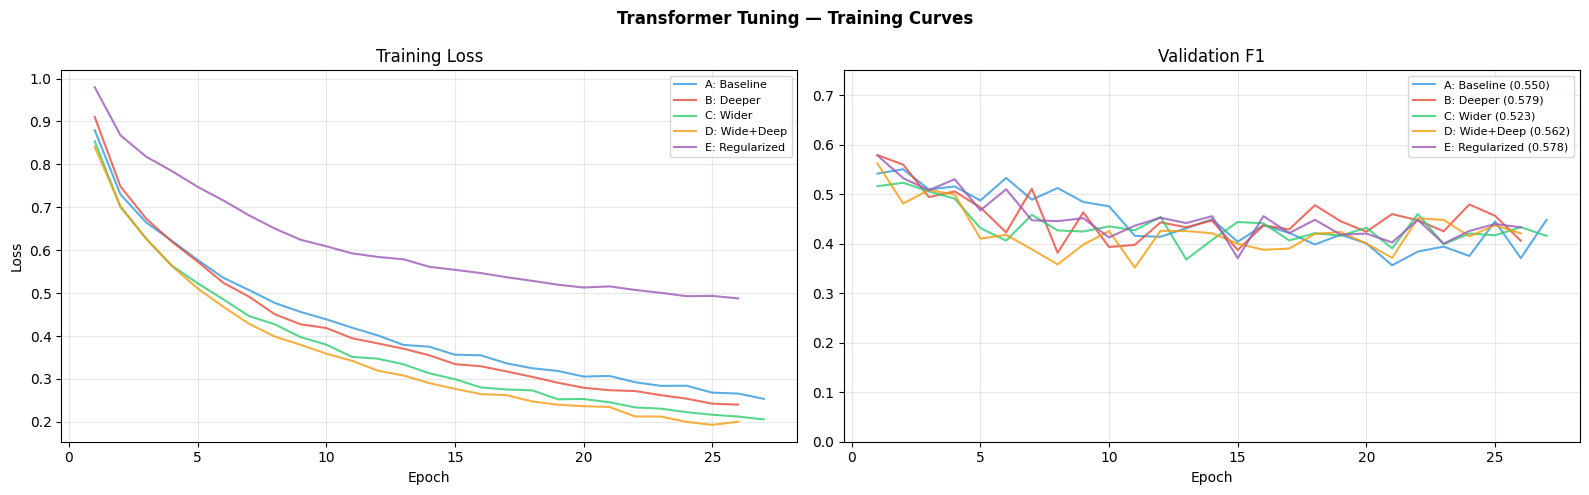

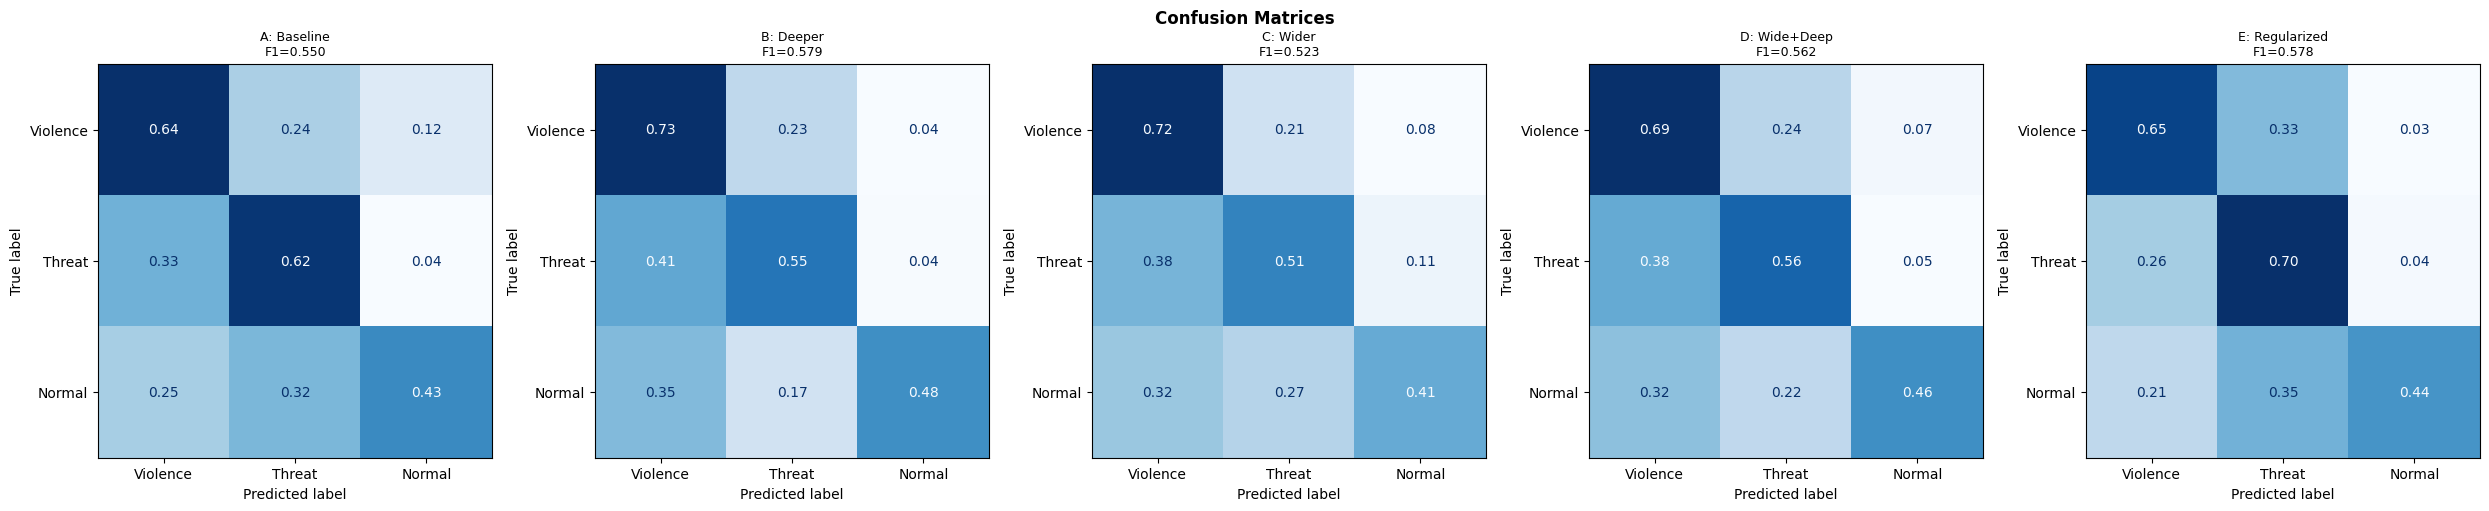

Diagnostics:
  A: Baseline              loss=0.2536(✅ learning)  spread=0.077(⚠)  best_ep=2
  B: Deeper                loss=0.2402(✅ learning)  spread=0.073(⚠)  best_ep=1
  C: Wider                 loss=0.2058(✅ learning)  spread=0.034(✅)  best_ep=2
  D: Wide+Deep             loss=0.2004(✅ learning)  spread=0.036(✅)  best_ep=1
  E: Regularized           loss=0.4878(✅ learning)  spread=0.048(✅)  best_ep=1

  📈 B: Deeper improved over previous Transformer
     0.5530 → 0.5788 (+0.0258)
     Gap to CNN+LSTM v3: 0.0592

  Best config: d=128 L=4 H=4
  Violence recall: 0.7325
  Threat recall:   0.5475
  Normal recall:   0.4800
  Params:          577,411

  Deployment recommendation:
  → Use as COMPLEMENTARY to CNN+LSTM v3 in dual-channel pipeline
    Skeleton excels at violence/threat, CNN+LSTM excels at Normal recall

  Best weights: runs/M4B_classifier/TransformerTuning/B_Deeper.pt


In [5]:
def get_m(yt, yp, cls, metric='recall'):
    ci = TARGET_CLASSES.index(cls)
    fn = recall_score if metric == 'recall' else precision_score
    r = fn(yt, yp, labels=[ci], average=None, zero_division=0)
    return float(r[0]) if len(r) > 0 else 0.0

# ── Master table ──────────────────────────────────────────────────────────────
print('='*95)
print('  TRANSFORMER TUNING — Results')
print('='*95)
print(f'  {"Config":<24} {"d":>4} {"L":>2} {"H":>2} {"Params":>8} {"F1":>7} {"Acc":>7} {"VioR":>6} {"ThrR":>6} {"NorR":>6} {"Time":>7}')
print('  ' + '-'*88)

# Reference rows
print(f'  {"CNN+LSTM v3 (ref)":<24} {"":>4} {"":>2} {"":>2} {"2.3M":>8} {"0.638":>7} {"0.668":>7} {"0.57":>6} {"0.26":>6} {"0.92":>6} {"3.5h":>7}')
print(f'  {"Prev Transformer":<24} {"128":>4} {"2":>2} {"4":>2} {"312K":>8} {"0.553":>7} {"0.549":>7} {"0.62":>6} {"0.65":>6} {"0.43":>6} {"21m":>7}')
print('  ' + '-'*88)

best_r = None
for r in results:
    cfg = r['config']
    yt, yp = r['y_true'], r['y_pred']
    acc = accuracy_score(yt, yp)
    vr = get_m(yt, yp, 'Violence')
    tr = get_m(yt, yp, 'Threat')
    nr = get_m(yt, yp, 'Normal')
    pk = f'{r["params"]/1000:.0f}K'
    m, s = divmod(int(r['elapsed']), 60)
    if best_r is None or r['best_f1'] > best_r['best_f1']:
        best_r = r
    print(f'  {r["name"]:<24} {cfg["d_model"]:>4} {cfg["num_layers"]:>2} {cfg["nhead"]:>2} {pk:>8} {r["best_f1"]:>7.4f} {acc:>7.4f} {vr:>6.2f} {tr:>6.2f} {nr:>6.2f} {m}m{s:02d}s')

print('  ' + '-'*88)
print(f'  Winner: {best_r["name"]} (F1={best_r["best_f1"]:.4f})')
print('='*95)

# ── Per-class for winner ──────────────────────────────────────────────────────
print(f'\nPer-class — {best_r["name"]}:')
print(classification_report(best_r['y_true'], best_r['y_pred'],
      target_names=TARGET_CLASSES, zero_division=0))

# ── Training curves ───────────────────────────────────────────────────────────
colors = ['#3498DB', '#E74C3C', '#2ECC71', '#F39C12', '#9B59B6']
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for r, c in zip(results, colors):
    ep = range(1, len(r['history']['f1']) + 1)
    axes[0].plot(ep, r['history']['loss'], '-', color=c, linewidth=1.5,
                 label=r['name'], alpha=0.8)
    axes[1].plot(ep, r['history']['f1'], '-', color=c, linewidth=1.5,
                 label=f'{r["name"]} ({r["best_f1"]:.3f})', alpha=0.8)

axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3); axes[0].legend(fontsize=8)
axes[1].set_title('Validation F1'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 0.75); axes[1].grid(alpha=0.3); axes[1].legend(fontsize=8)

plt.suptitle('Transformer Tuning — Training Curves', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Confusion matrices ───────────────────────────────────────────────────────
n = len(results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1: axes = [axes]
for ax, r in zip(axes, results):
    cm = confusion_matrix(r['y_true'], r['y_pred'])
    cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(cm_n, display_labels=TARGET_CLASSES).plot(
        ax=ax, colorbar=False, cmap='Blues', values_format='.2f')
    ax.set_title(f'{r["name"]}\nF1={r["best_f1"]:.3f}', fontsize=9)
plt.suptitle('Confusion Matrices', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Diagnostics ───────────────────────────────────────────────────────────────
print('Diagnostics:')
for r in results:
    fl = r['history']['loss'][-1]
    tag = '✅ learning' if fl > 0.1 else ('⚠ mild overfit' if fl > 0.01 else '❌ memorizing')
    sp = max(r['history']['f1'][-5:])-min(r['history']['f1'][-5:]) if len(r['history']['f1'])>=5 else 0
    st = '✅' if sp < 0.06 else '⚠'
    be = np.argmax(r['history']['f1']) + 1
    print(f'  {r["name"]:<24} loss={fl:.4f}({tag})  spread={sp:.3f}({st})  best_ep={be}')

# ── Final verdict ─────────────────────────────────────────────────────────────
cnn_f1 = 0.638
prev_skel = 0.553
w = best_r['best_f1']

print()
print('='*70)
if w > cnn_f1:
    print(f'  🏆 {best_r["name"]} BEATS CNN+LSTM v3!')
    print(f'     Skeleton-Transformer: {w:.4f} vs CNN+LSTM: {cnn_f1:.4f}')
    print(f'     Skeleton approach has surpassed pixel-based.')
elif w > prev_skel + 0.01:
    gap = cnn_f1 - w
    print(f'  📈 {best_r["name"]} improved over previous Transformer')
    print(f'     {prev_skel:.4f} → {w:.4f} (+{w-prev_skel:.4f})')
    print(f'     Gap to CNN+LSTM v3: {gap:.4f}')
else:
    print(f'  📊 Tuning did not significantly improve over previous best')
    print(f'     Best: {w:.4f}, Previous: {prev_skel:.4f}, CNN+LSTM: {cnn_f1:.4f}')

vr_w = get_m(best_r['y_true'], best_r['y_pred'], 'Violence')
tr_w = get_m(best_r['y_true'], best_r['y_pred'], 'Threat')
nr_w = get_m(best_r['y_true'], best_r['y_pred'], 'Normal')

print()
print(f'  Best config: d={best_r["config"]["d_model"]} L={best_r["config"]["num_layers"]} H={best_r["config"]["nhead"]}')
print(f'  Violence recall: {vr_w:.4f}')
print(f'  Threat recall:   {tr_w:.4f}')
print(f'  Normal recall:   {nr_w:.4f}')
print(f'  Params:          {best_r["params"]:,}')

print()
print('  Deployment recommendation:')
if nr_w > 0.7 and w > 0.55:
    print(f'  → Skeleton-Transformer can replace CNN+LSTM v3')
    print(f'    Better threat detection with fewer false alarms')
elif vr_w > 0.7 or tr_w > 0.6:
    print(f'  → Use as COMPLEMENTARY to CNN+LSTM v3 in dual-channel pipeline')
    print(f'    Skeleton excels at violence/threat, CNN+LSTM excels at Normal recall')
else:
    print(f'  → CNN+LSTM v3 remains the primary model for deployment')
    print(f'    Skeleton-Transformer is a strong future direction')
print('='*70)

bw = best_r["name"].replace(" ","_").replace(":","")
print(f'\n  Best weights: {SAVE_DIR}/{bw}.pt')
